Dataset Preview:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


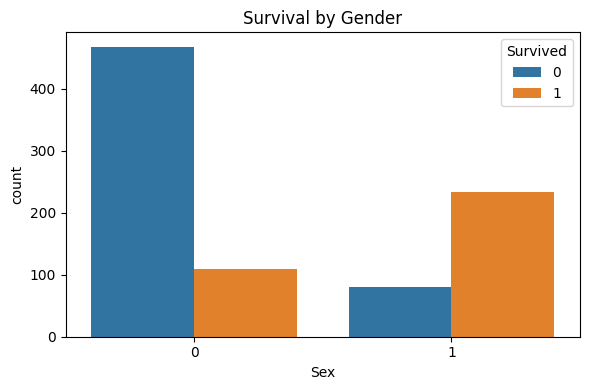

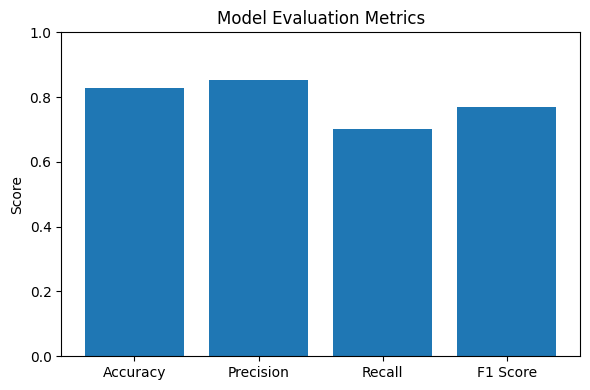

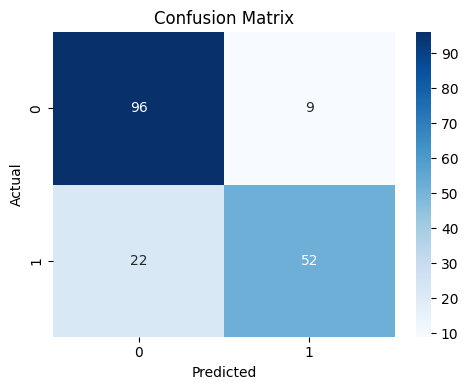

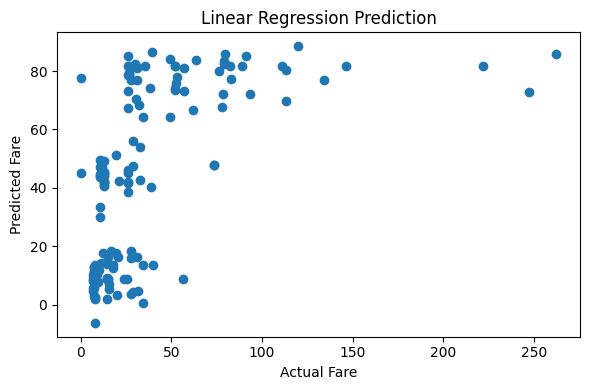

In [4]:
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("train.csv")

print("Dataset Preview:")
display(df.head())

# -----------------------------
# Data Preprocessing
# -----------------------------

df = df[['Survived','Pclass','Sex','Age','Fare','Embarked','SibSp','Parch']]

df['Sex'] = df['Sex'].map({'male':0,'female':1})

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})

# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# -----------------------------
# Graph: Survival by Gender
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.tight_layout()
plt.show()

# -----------------------------
# Prepare Data
# -----------------------------
X = df[['Pclass','Sex','Age','Fare','Embarked','FamilySize','IsAlone']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Random Forest Model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# -----------------------------
# Metrics Visualization
# -----------------------------
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0,1)
plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# -----------------------------
# Linear Regression
# Predict Fare
# -----------------------------
X_reg = df[['Age','Pclass']]
y_reg = df['Fare']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

fare_pred = reg_model.predict(X_test_r)

plt.figure(figsize=(6,4))
plt.scatter(y_test_r, fare_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression Prediction")
plt.tight_layout()
plt.show()